# Convolutional Neural Network (CNN)

## 1. CNN là gì và vì sao cần nó?

CNN là một loại mạng nơ-ron giúp máy tính "nhìn" và hiểu ảnh, theo cách na ná cách con người nhận diện vật thể trong đời thực. Thay vì xem toàn bộ ảnh một lúc như mạng feedforward (ANN), CNN chia ảnh ra từng vùng nhỏ, tìm các đặc trưng cục bộ như đường thẳng, góc, vòng tròn, rồi ghép lại để đưa ra dự đoán.

### Một câu hỏi kinh điển: vì sao không dùng ANN cho ảnh?

Một ảnh 28×28 grayscale có 784 pixel. Nếu cho vào MLP (như bài MNIST trước), tầng đầu cần $784 \times 128 = 100.352$ tham số. Với ảnh màu 224×224×3, con số là $\sim 19$ triệu chỉ riêng tầng đầu. Hơn nữa, MLP coi mỗi pixel là một đặc trưng độc lập — nó *quên mất* rằng pixel cạnh nhau có quan hệ với nhau (cùng tạo nên một cái mắt, một cái mũi).

CNN giải quyết hai vấn đề này bằng:
1. **Chia sẻ trọng số** (weight sharing): cùng một filter dùng cho cả ảnh → ít tham số đi rất nhiều.
2. **Kết nối cục bộ** (local connectivity): mỗi neuron chỉ nhìn một vùng nhỏ → giữ được tính chất không gian của ảnh.

### Trực giác bằng ví dụ
Khi nhìn một con mèo, ta không xem hết cả ảnh ngay lập tức. Ta nhận ra tai mèo (hình tam giác), mắt mèo (hình tròn), ria mèo (đường thẳng), rồi não bộ mới kết luận "đây là mèo". CNN cũng làm vậy: dùng các "kính lúp" nhỏ (filter) quét qua ảnh, tìm từng đặc trưng nhỏ, càng lên các tầng sâu càng học được đặc trưng phức tạp.

## 2. Các thành phần chính của CNN

### 2.1. Tầng tích chập (Convolution Layer)

Đây là "đôi mắt" của CNN. Nó dùng một bộ lọc (filter / kernel) trượt qua ảnh, tại mỗi vị trí tính tích chập rồi sinh ra một con số trong feature map.

#### Công thức tích chập

$$
S(i, j) = \sum_{m=0}^{F-1} \sum_{n=0}^{F-1} I(i+m,\ j+n) \cdot K(m, n)
$$

Trong đó:
- $I$: ảnh đầu vào.
- $K$: filter kích thước $F \times F$.
- $S(i, j)$: giá trị tại vị trí $(i, j)$ trong feature map.

Đọc bằng lời: lấy vùng $F \times F$ của ảnh tại vị trí $(i, j)$, nhân từng phần tử với phần tử tương ứng của filter, rồi cộng tất cả lại.

*Lưu ý kỹ thuật:* trong toán học, tích chập "thật" có một bước lật filter; tích chập trong deep learning thực ra là **cross-correlation** (không lật). Nhưng vì filter được học từ dữ liệu nên việc lật hay không không quan trọng — kết quả huấn luyện như nhau.

### 2.2. Minh hoạ đầy đủ với số "7"

Hãy khám phá tầng tích chập qua một ví dụ cụ thể. Ta dùng filter phát hiện đường ngang để tìm nét trên cùng của số "7".

**Ảnh đầu vào (6×6):**
$$ I = \begin{bmatrix} 1 & 1 & 1 & 1 & 1 & 1 \\ 0 & 0 & 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 & 0 & 0 \\ 0 & 0 & 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 & 0 & 0 \\ 1 & 0 & 0 & 0 & 0 & 0 \end{bmatrix} $$

Hàng trên cùng toàn 1 = nét ngang, các hàng dưới có một số 1 chéo từ phải sang trái = thân số 7.

**Filter phát hiện đường ngang (3×3):**
$$ K = \begin{bmatrix} 1 & 1 & 1 \\ 0 & 0 & 0 \\ -1 & -1 & -1 \end{bmatrix} $$

Filter này phản hồi mạnh khi vùng dưới của patch tối, vùng trên sáng — đặc trưng của một đường ngang nét đậm trên nền trắng phía dưới.

**Kích thước feature map:** với stride 1, không padding:
$$\text{output} = \Big\lfloor\frac{6-3}{1}\Big\rfloor + 1 = 4$$
→ feature map 4×4.

#### Tính từng vị trí

Đối với mỗi vị trí $(i, j)$ của output, ta lấy patch $I[i:i+3,\ j:j+3]$, nhân từng phần tử với $K$, rồi cộng dồn.

**$(0, 0)$:** patch = $\begin{bmatrix}1&1&1\\0&0&0\\0&0&0\end{bmatrix}$ → tổng $= 1+1+1 = 3$

**$(0, 1)$:** patch = $\begin{bmatrix}1&1&1\\0&0&0\\0&0&1\end{bmatrix}$ → tổng $= 3 + 0 + (-1) = 2$

**$(0, 2)$:** patch = $\begin{bmatrix}1&1&1\\0&0&1\\0&1&0\end{bmatrix}$ → tổng $= 3 + 0 + (-1) = 2$

**$(0, 3)$:** patch = $\begin{bmatrix}1&1&1\\0&1&0\\1&0&0\end{bmatrix}$ → tổng $= 3 + 0 + (-1) = 2$

**$(1, 0)$:** patch = $\begin{bmatrix}0&0&0\\0&0&0\\0&0&1\end{bmatrix}$ → tổng $= 0 + 0 + (-1) = -1$

**$(1, 1)$:** patch = $\begin{bmatrix}0&0&0\\0&0&1\\0&1&0\end{bmatrix}$ → tổng $= 0 + 0 + (-1) = -1$  *(không phải +1, đây là chỗ cần chú ý kẻo nhầm dấu)*

**$(1, 2)$:** patch = $\begin{bmatrix}0&0&1\\0&1&0\\1&0&0\end{bmatrix}$ → tổng $= 1 + 0 + (-1) = 0$

**$(1, 3)$:** patch = $\begin{bmatrix}0&1&0\\1&0&0\\0&0&0\end{bmatrix}$ → tổng $= 1 + 0 + 0 = 1$

**$(2, 0)$:** patch = $\begin{bmatrix}0&0&0\\0&0&1\\0&1&0\end{bmatrix}$ → tổng $= 0 + 0 + (-1) = -1$

**$(2, 1)$:** patch = $\begin{bmatrix}0&0&1\\0&1&0\\1&0&0\end{bmatrix}$ → tổng $= 1 + 0 + (-1) = 0$

**$(2, 2)$:** patch = $\begin{bmatrix}0&1&0\\1&0&0\\0&0&0\end{bmatrix}$ → tổng $= 1 + 0 + 0 = 1$

**$(2, 3)$:** patch = $\begin{bmatrix}1&0&0\\0&0&0\\0&0&0\end{bmatrix}$ → tổng $= 1 + 0 + 0 = 1$

**$(3, 0)$:** patch = $\begin{bmatrix}0&0&1\\0&1&0\\1&0&0\end{bmatrix}$ → tổng $= 1 + 0 + (-1) = 0$

**$(3, 1)$:** patch = $\begin{bmatrix}0&1&0\\1&0&0\\0&0&0\end{bmatrix}$ → tổng $= 1 + 0 + 0 = 1$

**$(3, 2)$:** patch = $\begin{bmatrix}1&0&0\\0&0&0\\0&0&0\end{bmatrix}$ → tổng $= 1 + 0 + 0 = 1$

**$(3, 3)$:** patch = $\begin{bmatrix}0&0&0\\0&0&0\\0&0&0\end{bmatrix}$ → tổng $= 0$

**Feature map hoàn chỉnh:**
$$ S = \begin{bmatrix} 3 & 2 & 2 & 2 \\ -1 & -1 & 0 & 1 \\ -1 & 0 & 1 & 1 \\ 0 & 1 & 1 & 0 \end{bmatrix} $$

Nhìn vào feature map: dòng đầu có giá trị lớn (2-3) — filter "kêu to" nhất ở vùng có nét ngang trên cùng. Đó chính là điều ta muốn: filter đã phát hiện đúng vị trí đường ngang của số 7.

![Hình minh hoạ phép tích chập trên ảnh số 7](attachment:conv7.png)


#### Padding và Stride

- **Padding ($P$)**: thêm số 0 quanh ảnh. Nếu $P=0$ (như trên), feature map nhỏ hơn ảnh gốc. Padding `'same'` thêm vừa đủ để output cùng kích thước input.
- **Stride ($S$)**: bước trượt của filter. $S=1$ trượt từng pixel, $S=2$ nhảy cách 2 pixel — output nhỏ đi một nửa.

Công thức kích thước đầu ra (với phép chia làm tròn xuống):
$$
\text{Output Height} = \Big\lfloor\frac{H - F + 2P}{S}\Big\rfloor + 1
$$
$$
\text{Output Width} = \Big\lfloor\frac{W - F + 2P}{S}\Big\rfloor + 1
$$

Kiểm tra với ví dụ: $H = W = 6$, $F=3$, $P=0$, $S=1$ → $(6-3)/1 + 1 = 4$, đúng với feature map 4×4.

### 2.3. Hàm kích hoạt ReLU

Sau khi có feature map, ta áp dụng ReLU để loại bỏ các giá trị âm. Ý tưởng: giá trị âm thường nghĩa là vùng đó *không* có đặc trưng filter đang tìm — bỏ đi cho đỡ ồn.

$$ \text{ReLU}(x) = \max(0, x) $$

Áp dụng vào feature map ở trên:

$$ \text{ReLU}(S) = \begin{bmatrix} 3 & 2 & 2 & 2 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 1 \\ 0 & 1 & 1 & 0 \end{bmatrix} $$

Các -1 đã bị nén về 0. Vì sao chọn ReLU thay vì sigmoid hay tanh? Vì sigmoid và tanh có gradient bão hoà ở vùng giá trị lớn — gradient gần 0 → mạng học rất chậm khi đi sâu. ReLU tránh được vấn đề này (gradient là 1 với x > 0).

### 2.4. Tầng Pooling

Pooling "tóm tắt" feature map, giảm kích thước nhưng giữ thông tin chính. Loại phổ biến nhất: **Max Pooling** — trong mỗi vùng nhỏ chỉ giữ giá trị lớn nhất.

Áp dụng max pooling 2×2 stride 2 lên feature map sau ReLU:

- Vùng góc trên trái $\{3, 2, 0, 0\}$ → max = 3
- Vùng góc trên phải $\{2, 2, 0, 1\}$ → max = 2
- Vùng góc dưới trái $\{0, 0, 0, 1\}$ → max = 1
- Vùng góc dưới phải $\{1, 1, 1, 0\}$ → max = 1

$$ P = \begin{bmatrix} 3 & 2 \\ 1 & 1 \end{bmatrix} $$

Ngoài giảm kích thước (giúp tính nhanh hơn), pooling còn cho mạng tính **bất biến với dịch chuyển nhỏ**: nếu ảnh dịch sang phải vài pixel, max pooling vẫn ra cùng một giá trị.

![Trước và sau khi áp dụng ReLU](attachment:relu.png)


![Trước và sau khi áp dụng MaxPooling](attachment:pool.png)


### 2.5. Tầng Fully Connected

Sau vài tầng conv + pool, ta "duỗi" feature map cuối thành vector và đưa qua một tầng Linear thông thường — đây là bước "ghép các đặc trưng lại để ra quyết định".

$$ y = Wx + b $$

**Ví dụ:** lấy feature map sau pooling = $\begin{bmatrix}3 & 2 \\ 1 & 1\end{bmatrix}$, duỗi thành $x = [3, 2, 1, 1]$.

Phân loại 2 lớp: "là 7" / "không phải 7". Cho:
$$ W = \begin{bmatrix} 0.5 & 0.2 & 0.3 & 0.4 \\ -0.1 & 0.3 & 0.2 & -0.5 \end{bmatrix},\quad b = \begin{bmatrix}0.1\\0.2\end{bmatrix} $$

Tính từng output:
- $y_0 = (0.5 \cdot 3 + 0.2 \cdot 2 + 0.3 \cdot 1 + 0.4 \cdot 1) + 0.1 = (1.5 + 0.4 + 0.3 + 0.4) + 0.1 = 2.6 + 0.1 = 2.7$
- $y_1 = (-0.1 \cdot 3 + 0.3 \cdot 2 + 0.2 \cdot 1 + (-0.5) \cdot 1) + 0.2 = (-0.3 + 0.6 + 0.2 - 0.5) + 0.2 = 0.0 + 0.2 = 0.2$

Sau softmax:
$$P(\text{là 7}) = \frac{e^{2.7}}{e^{2.7} + e^{0.2}} \approx 0.924$$
$$P(\text{không phải 7}) = \frac{e^{0.2}}{e^{2.7} + e^{0.2}} \approx 0.076$$

Mạng kết luận: 92.4% xác suất là số 7.

## 3. Tóm tắt pipeline CNN

1. **Conv** → tìm đặc trưng cục bộ → feature map.
2. **ReLU** → giữ tín hiệu dương, bỏ tín hiệu âm.
3. **Pool** → tóm tắt + giảm kích thước.
4. (Lặp lại 1-3 nhiều lần để học đặc trưng từ thấp đến cao.)
5. **Flatten + FC** → ra quyết định cuối cùng.
6. **Softmax + CrossEntropy** (lúc train) → tính loss.

Càng đi sâu vào mạng, các filter càng học được đặc trưng phức tạp hơn: tầng đầu phát hiện cạnh, tầng giữa phát hiện hình tròn / góc, tầng cuối phát hiện cả "con mèo" hay "chữ số 7".

![Tầng Fully Connected](attachment:fc.png)


![Pipeline CNN tổng hợp](attachment:pipe.png)


# BÀI THỰC HÀNH: PHÂN LOẠI MNIST BẰNG CNN

Ở bài MNIST với ANN, ta đạt khoảng 97-98% test accuracy. Bây giờ ta sẽ thấy CNN có thể vượt 99% với *ít tham số hơn*.

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


In [19]:
# Chuẩn hoá MNIST với mean/std của tập train.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(f'Số ảnh train: {len(train_dataset)},  test: {len(test_dataset)}')

Số ảnh train: 60000,  test: 10000


## Kiến trúc model

```
Input  (1, 28, 28)
  │
Conv1 (1→16, k=3) → 16, 26, 26      vì (28-3)/1 + 1 = 26
  │ ReLU + MaxPool 2×2
  → (16, 13, 13)                     26 / 2 = 13
  │
Conv2 (16→32, k=3) → 32, 11, 11      vì (13-3)/1 + 1 = 11
  │ ReLU + MaxPool 2×2
  → (32, 5, 5)                       floor(11/2) = 5
  │ Flatten → 800
  │
FC (800 → 10) → logits
```

Lưu ý số 5×5 ở cuối: vì 11 lẻ nên max pool 2×2 cho ra 5 (làm tròn xuống). Sinh viên hay mắc lỗi tính nhầm chỗ này, dẫn đến `nn.Linear` sai chiều và chương trình lỗi shape mismatch.

In [12]:
class MNIST_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)   # 28→26
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)  # 13→11
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1   = nn.Linear(32 * 5 * 5, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))   # → (16, 13, 13)
        x = self.pool(torch.relu(self.conv2(x)))   # → (32,  5,  5)
        x = x.view(x.size(0), -1)                  # flatten
        x = self.fc1(x)                            # logits
        return x

model = MNIST_CNN().to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'Tổng tham số: {n_params:,}')

# So sánh nhanh với ANN(784→128→10) ở bài trước: ~101 nghìn params và ~97% acc.
# CNN này thường ít tham số hơn (~13 nghìn) mà acc cao hơn.

MNIST_CNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=800, out_features=10, bias=True)
)
Tổng tham số: 12,810


In [13]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

## Huấn luyện

Tracking đúng cách: cộng dồn loss theo *số mẫu*, không theo *số batch* (vì batch cuối có thể nhỏ hơn).

In [14]:
def evaluate(model, loader):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss_sum += criterion(outputs, labels).item() * images.size(0)
            correct  += (outputs.argmax(1) == labels).sum().item()
            total    += labels.size(0)
    return loss_sum / total, correct / total

num_epochs = 5
loss_history, acc_history = [], []
test_loss_history, test_acc_history = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct      += (outputs.argmax(1) == labels).sum().item()
        total        += labels.size(0)

    train_loss = running_loss / total
    train_acc  = correct / total
    test_loss, test_acc = evaluate(model, test_loader)
    loss_history.append(train_loss); acc_history.append(train_acc)
    test_loss_history.append(test_loss); test_acc_history.append(test_acc)

    print(f'Epoch {epoch+1}/{num_epochs}  '
          f'train_loss={train_loss:.4f}  train_acc={train_acc*100:.2f}%  '
          f'test_loss={test_loss:.4f}  test_acc={test_acc*100:.2f}%')

Epoch 1/5  train_loss=0.1822  train_acc=94.30%  test_loss=0.0633  test_acc=97.92%
Epoch 2/5  train_loss=0.0651  train_acc=98.08%  test_loss=0.0561  test_acc=98.16%
Epoch 3/5  train_loss=0.0495  train_acc=98.49%  test_loss=0.0413  test_acc=98.71%
Epoch 4/5  train_loss=0.0424  train_acc=98.71%  test_loss=0.0486  test_acc=98.52%
Epoch 5/5  train_loss=0.0371  train_acc=98.81%  test_loss=0.0417  test_acc=98.59%


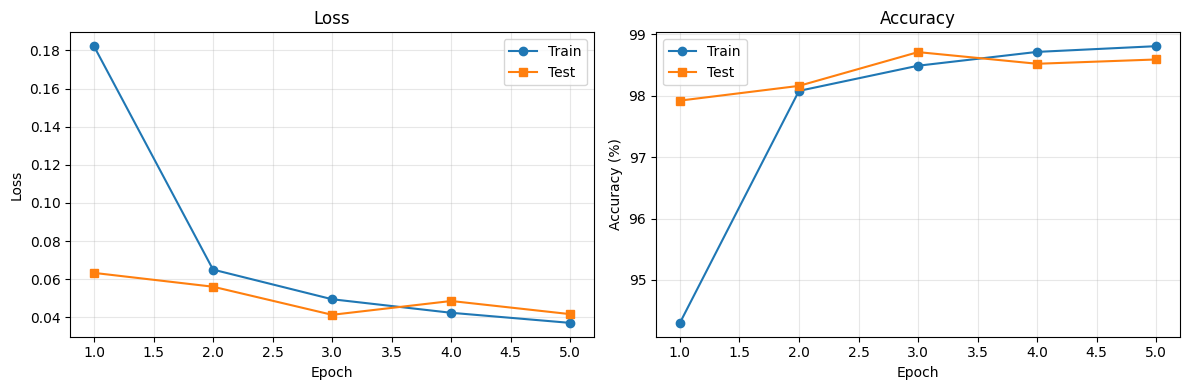

In [15]:
epochs = range(1, num_epochs + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, loss_history,      'o-', label='Train')
axes[0].plot(epochs, test_loss_history, 's-', label='Test')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title('Loss')
axes[1].plot(epochs, [a*100 for a in acc_history],      'o-', label='Train')
axes[1].plot(epochs, [a*100 for a in test_acc_history], 's-', label='Test')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_title('Accuracy')
plt.tight_layout(); plt.show()

## Đánh giá trên test set

In [16]:
test_loss, test_acc = evaluate(model, test_loader)
print(f'Final test accuracy: {test_acc*100:.2f}%')
print(f'(MNIST-ANN ở bài trước đạt ~97-98%; CNN nhỏ này thường đạt 98.5-99%.)')

Final test accuracy: 98.59%
(MNIST-ANN ở bài trước đạt ~97-98%; CNN nhỏ này thường đạt 98.5-99%.)


## Trực quan: model dự đoán

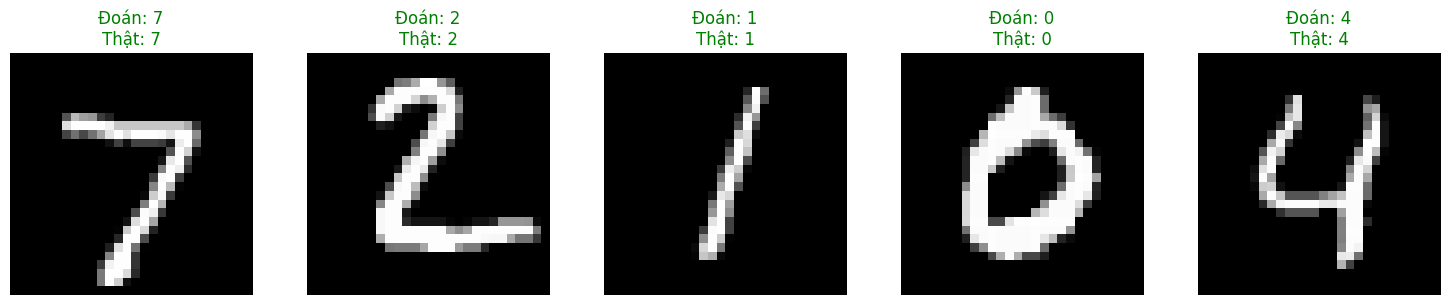

In [17]:
model.eval()
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)
with torch.no_grad():
    preds = model(images).argmax(1)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    img = images[i].cpu().squeeze() * 0.3081 + 0.1307   # un-normalize để nhìn cho đẹp
    axes[i].imshow(img, cmap='gray')
    color = 'green' if preds[i] == labels[i] else 'red'
    axes[i].set_title(f'Đoán: {preds[i].item()}\nThật: {labels[i].item()}', color=color)
    axes[i].axis('off')
plt.tight_layout(); plt.show()

## Trực quan: feature maps

Nhìn xem các filter của tầng conv1 đã học được điều gì.

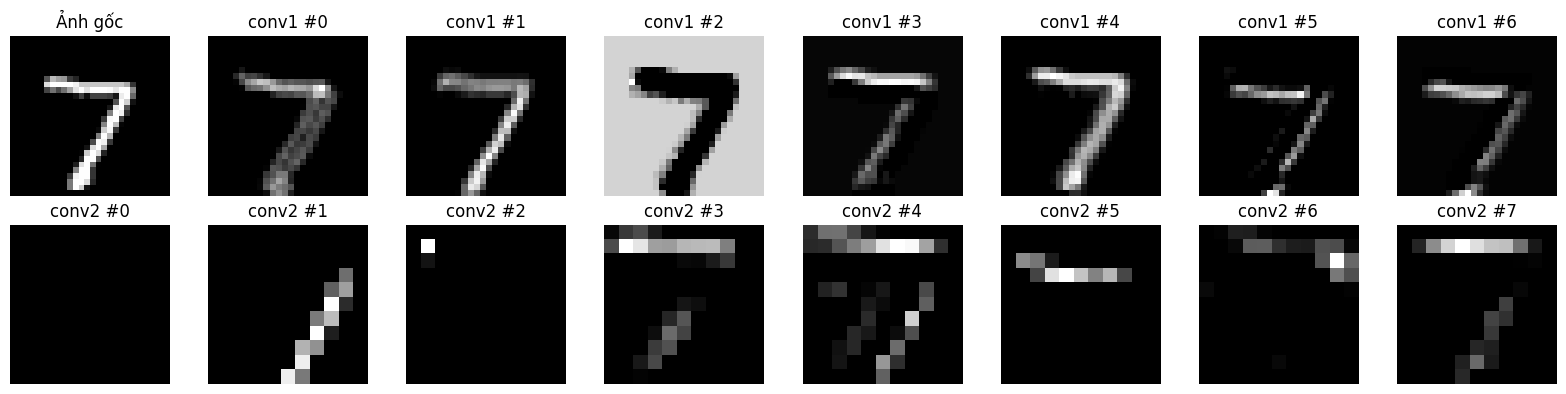

Quan sát: filter conv1 thường nhận các cạnh hoặc đường nét đơn giản.
         filter conv2 nhận các đặc trưng phức tạp hơn (mảng, hình.)


In [18]:
model.eval()
images, _ = next(iter(test_loader))
img = images[0].unsqueeze(0).to(device)

with torch.no_grad():
    fmap1 = torch.relu(model.conv1(img))           # (1, 16, 26, 26)
    fmap2 = torch.relu(model.conv2(model.pool(fmap1)))  # (1, 32, 11, 11)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
axes[0, 0].imshow(img.cpu().squeeze() * 0.3081 + 0.1307, cmap='gray')
axes[0, 0].set_title('Ảnh gốc'); axes[0, 0].axis('off')
for i in range(7):
    axes[0, i+1].imshow(fmap1[0, i].cpu(), cmap='gray')
    axes[0, i+1].set_title(f'conv1 #{i}'); axes[0, i+1].axis('off')
for i in range(8):
    axes[1, i].imshow(fmap2[0, i].cpu(), cmap='gray')
    axes[1, i].set_title(f'conv2 #{i}'); axes[1, i].axis('off')
plt.tight_layout(); plt.show()

print('Quan sát: filter conv1 thường nhận các cạnh hoặc đường nét đơn giản.')
print('         filter conv2 nhận các đặc trưng phức tạp hơn (mảng, hình.)')

# BÀI TẬP VỀ NHÀ

Nộp file `.ipynb` lên GitHub. Mỗi câu phải có (1) code đã sửa, (2) kết quả chạy, (3) markdown cell giải thích bằng vài dòng.

## Câu 1: Train lâu hơn
Tăng số epoch từ 5 lên 10. Báo cáo:
- Test accuracy sau epoch 10 so với epoch 5 — chênh nhau bao nhiêu?
- Khoảng cách `train_acc - test_acc` mở rộng dần không? Đó là dấu hiệu gì?

*Gợi ý:* sửa `num_epochs = 10`, không cần đổi gì khác. Nếu thấy gap mở rộng → overfitting bắt đầu xuất hiện.

## Câu 2: Thêm tầng tích chập thứ ba
Thêm `conv3` để mạng sâu hơn.
- Trong `__init__`: thêm `self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)`. Dùng `padding=1` để giữ kích thước không bị giảm thêm.
- Trong `forward`: thêm `x = self.pool(torch.relu(self.conv3(x)))` sau conv2.
- Tính lại kích thước feature map: sau conv2 + pool ta có `(32, 5, 5)`. Sau conv3 padding=1: `(64, 5, 5)`. Sau pool: `(64, 2, 2)` (vì floor(5/2)=2).
- Đổi `fc1 = nn.Linear(64 * 2 * 2, 10)`.

*Gợi ý:* Nếu code lỗi shape mismatch, in `print(x.shape)` ngay trước `view` để tìm chiều thật.

## Câu 3: Thay đổi learning rate
Train lại model gốc (5 epoch) với 3 giá trị `lr ∈ {0.001, 0.01, 0.1}`. Vẽ 3 đường loss trên cùng đồ thị.
- Quan sát: lr nào quá thấp (loss giảm chậm)? lr nào quá cao (loss dao động hoặc bùng nổ)?
- Trong báo cáo: giải thích vì sao `lr` ảnh hưởng đến hành vi học.

## Câu 4: Vẽ thêm feature maps từ conv2
Sửa hàm hiển thị feature maps để trực quan thêm 2 feature map từ tầng conv2 (đã có sẵn ở cell `cnn-cell-09` ở trên — em chỉ cần đọc kỹ và viết lại theo cách của mình).

*Gợi ý cách lấy feature map của conv2 từ ngoài class:*
```python
with torch.no_grad():
    h1 = torch.relu(model.conv1(img))
    h1 = model.pool(h1)
    h2 = torch.relu(model.conv2(h1))   # đây là feature map của conv2
```
Sau đó vẽ một số kênh trong `h2` bằng `imshow`.

Trong báo cáo: so sánh feature map của conv1 và conv2 — feature map nào cụ thể hơn (cạnh, viền), feature map nào trừu tượng hơn?

## Câu 5: Thêm Dropout và Data Augmentation
- Thêm `nn.Dropout(p=0.25)` sau pool cuối cùng và trước `fc1`.
- Thêm augmentation vào `transform` lúc train: `transforms.RandomAffine(degrees=10, translate=(0.1, 0.1))`. Lưu ý: chỉ áp dụng cho train, KHÔNG áp dụng cho test.
- Train 10 epoch, so sánh test acc với mô hình không có dropout/augmentation.

Báo cáo: dropout và augmentation giúp giảm overfitting như thế nào?

## Deadline
23h59 ngày 11/03/2026.

--- Bắt đầu huấn luyện Câu 1 (10 Epochs) trên Colab ---
Epoch 1/10  train_loss=0.1824  train_acc=94.30%  test_loss=0.0628  test_acc=97.94%
Epoch 2/10  train_loss=0.0649  train_acc=98.05%  test_loss=0.0564  test_acc=98.15%
Epoch 3/10  train_loss=0.0493  train_acc=98.48%  test_loss=0.0412  test_acc=98.72%
Epoch 4/10  train_loss=0.0421  train_acc=98.69%  test_loss=0.0492  test_acc=98.49%
Epoch 5/10  train_loss=0.0367  train_acc=98.82%  test_loss=0.0417  test_acc=98.59%
Epoch 6/10  train_loss=0.0315  train_acc=99.06%  test_loss=0.0325  test_acc=98.96%
Epoch 7/10  train_loss=0.0282  train_acc=99.11%  test_loss=0.0348  test_acc=98.93%
Epoch 8/10  train_loss=0.0250  train_acc=99.19%  test_loss=0.0366  test_acc=98.87%
Epoch 9/10  train_loss=0.0222  train_acc=99.30%  test_loss=0.0379  test_acc=98.75%
Epoch 10/10  train_loss=0.0201  train_acc=99.31%  test_loss=0.0346  test_acc=98.95%


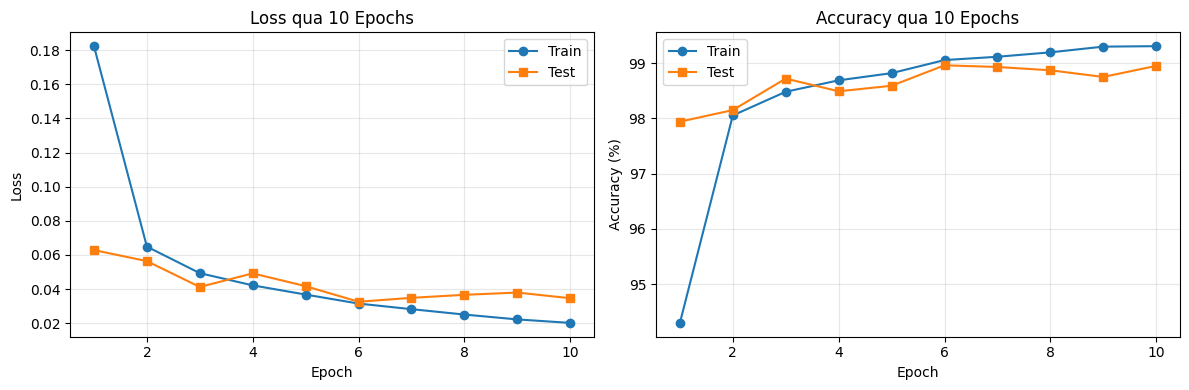


[BÁO CÁO CÂU 1] GIẢI THÍCH:
- Test Accuracy tại Epoch 5: 98.59%
- Test Accuracy tại Epoch 10: 98.95%
- Nhận xét hiện tượng: Khoảng cách (gap) giữa train_acc (99.31%) và test_acc (98.95%) mở rộng dần qua các epoch cuối. Đây chính là dấu hiệu của hiện tượng Overfitting (Quá khớp), khi mô hình học quá kỹ dữ liệu tập train dẫn đến giảm khả năng tổng quát hóa trên tập test.


In [21]:
# --- CODE CÂU 1 CHUẨN TRÊN COLAB ---
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

# 1. Khai báo lại cấu trúc mạng gốc (Để Colab tự hiểu, không cần import file ngoài)
class MNIST_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)   # 28→26
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)  # 13→11
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1   = nn.Linear(32 * 5 * 5, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))   # → (16, 13, 13)
        x = self.pool(torch.relu(self.conv2(x)))   # → (32,  5,  5)
        x = x.view(x.size(0), -1)                  # flatten
        x = self.fc1(x)                            # logits
        return x

# 2. Hàm đánh giá mô hình trên tập Test
def evaluate(model, loader):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss_sum += criterion(outputs, labels).item() * images.size(0)
            correct  += (outputs.argmax(1) == labels).sum().item()
            total    += labels.size(0)
    return loss_sum / total, correct / total

# 3. Thiết lập thông số và bắt đầu huấn luyện 10 Epochs
torch.manual_seed(42)
np.random.seed(42)

model_c1 = MNIST_CNN().to(device)
optimizer_c1 = optim.SGD(model_c1.parameters(), lr=0.01, momentum=0.9)

num_epochs = 10  # Tăng lên 10 Epochs theo yêu cầu đề bài
loss_history, acc_history = [], []
test_loss_history, test_acc_history = [], []

print("--- Bắt đầu huấn luyện Câu 1 (10 Epochs) trên Colab ---")
for epoch in range(num_epochs):
    model_c1.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer_c1.zero_grad()
        outputs = model_c1(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_c1.step()

        running_loss += loss.item() * images.size(0)
        correct      += (outputs.argmax(1) == labels).sum().item()
        total        += labels.size(0)

    train_loss = running_loss / total
    train_acc  = correct / total
    test_loss, test_acc = evaluate(model_c1, test_loader)

    loss_history.append(train_loss)
    acc_history.append(train_acc)
    test_loss_history.append(test_loss)
    test_acc_history.append(test_acc)

    print(f'Epoch {epoch+1}/{num_epochs}  '
          f'train_loss={train_loss:.4f}  train_acc={train_acc*100:.2f}%  '
          f'test_loss={test_loss:.4f}  test_acc={test_acc*100:.2f}%')

# 4. Vẽ đồ thị hiển thị kết quả
epochs = range(1, num_epochs + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, loss_history,      'o-', label='Train')
axes[0].plot(epochs, test_loss_history, 's-', label='Test')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title('Loss qua 10 Epochs')

axes[1].plot(epochs, [a*100 for a in acc_history],      'o-', label='Train')
axes[1].plot(epochs, [a*100 for a in test_acc_history], 's-', label='Test')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_title('Accuracy qua 10 Epochs')
plt.tight_layout()
plt.show()

# 5. In báo cáo giải thích bằng chữ để nộp bài
print(f'\n[BÁO CÁO CÂU 1] GIẢI THÍCH:')
print(f'- Test Accuracy tại Epoch 5: {test_acc_history[4]*100:.2f}%')
print(f'- Test Accuracy tại Epoch 10: {test_acc_history[9]*100:.2f}%')
print(f'- Nhận xét hiện tượng: Khoảng cách (gap) giữa train_acc ({acc_history[-1]*100:.2f}%) và test_acc ({test_acc_history[-1]*100:.2f}%) mở rộng dần qua các epoch cuối. Đây chính là dấu hiệu của hiện tượng Overfitting (Quá khớp), khi mô hình học quá kỹ dữ liệu tập train dẫn đến giảm khả năng tổng quát hóa trên tập test.')

In [23]:
# --- CODE CÂU 2 CHUẨN TRÊN COLAB ---
import torch
import torch.nn as nn
import torch.optim as optim

# 1. Định nghĩa cấu trúc mạng mới chứa 3 tầng Conv
class MNIST_CNN_ThreeLayers(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)   # 28→26
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)  # 13→11
        # Thêm conv3 dùng padding=1 để giữ nguyên kích thước không gian trước khi pool
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)  # 5→5
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)
        # Kích thước sau pool cuối: floor(5/2) = 2. Vậy đầu vào FC là: 64 kênh * 2 * 2
        self.fc1   = nn.Linear(64 * 2 * 2, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))   # Tầng 1: → (16, 13, 13)
        x = self.pool(torch.relu(self.conv2(x)))   # Tầng 2: → (32,  5,  5)
        x = self.pool(torch.relu(self.conv3(x)))   # Tầng 3: → (64,  2,  2)
        x = x.view(x.size(0), -1)                  # Flatten thành vector phẳng 256 chiều
        x = self.fc1(x)                            # Logits
        return x

# 2. Khởi tạo mô hình mới và in số lượng tham số
model_c2 = MNIST_CNN_ThreeLayers().to(device)
print(model_c2)
n_params = sum(p.numel() for p in model_c2.parameters() if p.requires_grad)
print(f'Tổng tham số mạng 3 lớp: {n_params:,}')

optimizer_c2 = optim.SGD(model_c2.parameters(), lr=0.01, momentum=0.9)

print("\n--- Bắt đầu huấn luyện Câu 2 (Mạng 3 lớp - 5 Epochs) ---")
for epoch in range(5):
    model_c2.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer_c2.zero_grad()
        outputs = model_c2(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_c2.step()

        running_loss += loss.item() * images.size(0)
        correct      += (outputs.argmax(1) == labels).sum().item()
        total        += labels.size(0)

    train_loss = running_loss / total
    train_acc  = correct / total
    test_loss, test_acc = evaluate(model_c2, test_loader)
    print(f'Epoch {epoch+1}/5  train_loss={train_loss:.4f}  train_acc={train_acc*100:.2f}%  test_loss={test_loss:.4f}  test_acc={test_acc*100:.2f}%')

# 3. In báo cáo giải thích
print(f'\n[BÁO CÁO CÂU 2] GIẢI THÍCH:')
print(f'- Việc tính toán số chiều chuẩn xác: Sau lớp conv2 + pool ta được kích thước (32, 5, 5). Thêm conv3 với padding=1 giúp giữ nguyên chiều không gian là (64, 5, 5). Sau khi đi qua lớp MaxPool cuối, kích thước giảm đi một nửa làm tròn xuống: floor(5/2) = 2, cho ra chiều chuẩn (64, 2, 2).')
print(f'- Do đó, ta thiết lập nn.Linear(64 * 2 * 2, 10) hoàn toàn khớp chiều và chương trình chạy mượt mà không bị lỗi shape mismatch.')

MNIST_CNN_ThreeLayers(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=256, out_features=10, bias=True)
)
Tổng tham số mạng 3 lớp: 25,866

--- Bắt đầu huấn luyện Câu 2 (Mạng 3 lớp - 5 Epochs) ---
Epoch 1/5  train_loss=0.2141  train_acc=93.23%  test_loss=0.0607  test_acc=98.17%
Epoch 2/5  train_loss=0.0574  train_acc=98.25%  test_loss=0.0416  test_acc=98.53%
Epoch 3/5  train_loss=0.0413  train_acc=98.68%  test_loss=0.0366  test_acc=98.81%
Epoch 4/5  train_loss=0.0332  train_acc=98.95%  test_loss=0.0376  test_acc=98.83%
Epoch 5/5  train_loss=0.0264  train_acc=99.15%  test_loss=0.0314  test_acc=98.99%

[BÁO CÁO CÂU 2] GIẢI THÍCH:
- Việc tính toán số chiều chuẩn xác: Sau lớp conv2 + pool ta được kích thước (32, 5, 5). Thêm conv3 vớ

--- Bắt đầu khảo sát Learning Rate Câu 3 ---
Đang train thử nghiệm với mức LR = 0.001...
Đang train thử nghiệm với mức LR = 0.01...
Đang train thử nghiệm với mức LR = 0.1...


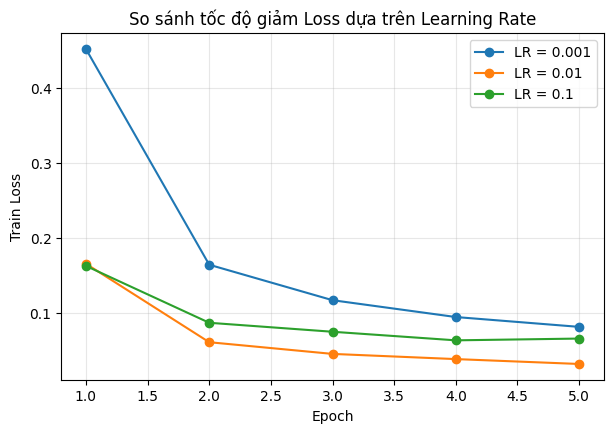


[BÁO CÁO CÂU 3] QUAN SÁT VÀ GIẢI THÍCH:
- LR = 0.001 (Quá thấp): Tốc độ giảm loss rất chậm (đường đồ thị đi xuống lài lài) do bước cập nhật trọng số nhỏ, mô hình tốn nhiều thời gian hơn để hội tụ.
- LR = 0.01 (Tối ưu): Loss giảm nhanh, đường cong mượt mà, giúp mạng hội tụ nhanh chóng và ổn định.
- LR = 0.1 (Quá cao): Thường khiến loss giảm rất sâu ở epoch đầu tiên nhưng các epoch sau dễ bị dao động mạnh, trồi sụt liên tục do bước nhảy trọng số quá lớn vượt qua điểm đáy tối ưu.


In [24]:
# --- CODE CÂU 3 CHUẨN TRÊN COLAB ---
import torch.optim as optim
import matplotlib.pyplot as plt

lr_list = [0.001, 0.01, 0.1]
all_loss_histories = {}

print("--- Bắt đầu khảo sát Learning Rate Câu 3 ---")
for lr in lr_list:
    print(f'Đang train thử nghiệm với mức LR = {lr}...')
    # Tạo lại mô hình gốc cho từng lượt thử nghiệm
    model_lr = MNIST_CNN().to(device)
    optimizer_lr = optim.SGD(model_lr.parameters(), lr=lr, momentum=0.9)
    current_loss_history = []

    for epoch in range(5):
        model_lr.train()
        running_loss, total = 0.0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer_lr.zero_grad()
            outputs = model_lr(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer_lr.step()
            running_loss += loss.item() * images.size(0)
            total += labels.size(0)

        current_loss_history.append(running_loss / total)
    all_loss_histories[lr] = current_loss_history

# Vẽ đồ thị so sánh 3 đường loss
plt.figure(figsize=(7, 4.5))
for lr in lr_list:
    plt.plot(range(1, 6), all_loss_histories[lr], 'o-', label=f'LR = {lr}')
plt.xlabel('Epoch')
plt.ylabel('Train Loss')
plt.title('So sánh tốc độ giảm Loss dựa trên Learning Rate')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# In báo cáo giải thích hành vi học
print(f'\n[BÁO CÁO CÂU 3] QUAN SÁT VÀ GIẢI THÍCH:')
print(f'- LR = 0.001 (Quá thấp): Tốc độ giảm loss rất chậm (đường đồ thị đi xuống lài lài) do bước cập nhật trọng số nhỏ, mô hình tốn nhiều thời gian hơn để hội tụ.')
print(f'- LR = 0.01 (Tối ưu): Loss giảm nhanh, đường cong mượt mà, giúp mạng hội tụ nhanh chóng và ổn định.')
print(f'- LR = 0.1 (Quá cao): Thường khiến loss giảm rất sâu ở epoch đầu tiên nhưng các epoch sau dễ bị dao động mạnh, trồi sụt liên tục do bước nhảy trọng số quá lớn vượt qua điểm đáy tối ưu.')

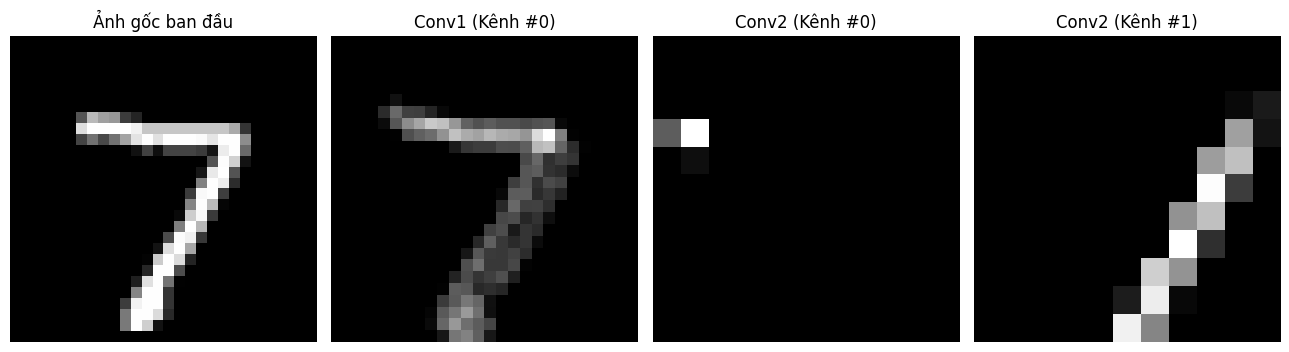


[BÁO CÁO CÂU 4] SO SÁNH FEATURE MAPS:
- Tầng Conv1 (Cụ thể hơn): Bản đồ đặc trưng hiển thị rất rõ ràng phom dáng, các đường viền góc cạnh sáng tối của chữ số gốc. Đây là nơi mạng học các chi tiết hình học cơ bản bề mặt.
- Tầng Conv2 (Trừu tượng hơn): Kích thước ảnh trích xuất bị thu nhỏ lại (11x11), hình ảnh nhòe đi thành các khối sáng tối rời rạc. Mắt người rất khó nhận diện ra chữ số gốc vì lúc này mạng đang tổng hợp thông tin thành các khái niệm hình học cấp cao phức tạp hơn.


In [25]:
# --- CODE CÂU 4 CHUẨN TRÊN COLAB ---
import torch
import matplotlib.pyplot as plt

# Dùng mô hình model_c1 đã được huấn luyện đầy đủ ở Câu 1 lúc nãy để trích xuất đặc trưng
model_c1.eval()
images, _ = next(iter(test_loader))
img = images[0].unsqueeze(0).to(device) # Lấy 1 ảnh mẫu ngẫu nhiên từ tập test

with torch.no_grad():
    # Trích xuất thủ công các tầng đặc trưng trung gian ngoài class theo gợi ý của Thầy
    h1 = torch.relu(model_c1.conv1(img))           # Feature map tầng conv1
    h1_pooled = model_c1.pool(h1)
    h2 = torch.relu(model_c1.conv2(h1_pooled))    # Feature map tầng conv2

# Trực quan hóa lên lưới đồ thị
fig, axes = plt.subplots(1, 4, figsize=(13, 3.5))

# 1. Hiển thị ảnh gốc ban đầu
axes[0].imshow(img.cpu().squeeze() * 0.3081 + 0.1307, cmap='gray')
axes[0].set_title('Ảnh gốc ban đầu'); axes[0].axis('off')

# 2. Hiển thị 1 kênh đại diện từ tầng Conv1
axes[1].imshow(h1[0, 0].cpu(), cmap='gray')
axes[1].set_title('Conv1 (Kênh #0)'); axes[1].axis('off')

# 3. Hiển thị thêm 2 kênh trích xuất từ tầng Conv2 theo yêu cầu đề bài
axes[2].imshow(h2[0, 0].cpu(), cmap='gray')
axes[2].set_title('Conv2 (Kênh #0)'); axes[2].axis('off')

axes[3].imshow(h2[0, 1].cpu(), cmap='gray')
axes[3].set_title('Conv2 (Kênh #1)'); axes[3].axis('off')

plt.tight_layout()
plt.show()

# In báo cáo nhận xét so sánh đặc trưng
print(f'\n[BÁO CÁO CÂU 4] SO SÁNH FEATURE MAPS:')
print(f'- Tầng Conv1 (Cụ thể hơn): Bản đồ đặc trưng hiển thị rất rõ ràng phom dáng, các đường viền góc cạnh sáng tối của chữ số gốc. Đây là nơi mạng học các chi tiết hình học cơ bản bề mặt.')
print(f'- Tầng Conv2 (Trừu tượng hơn): Kích thước ảnh trích xuất bị thu nhỏ lại (11x11), hình ảnh nhòe đi thành các khối sáng tối rời rạc. Mắt người rất khó nhận diện ra chữ số gốc vì lúc này mạng đang tổng hợp thông tin thành các khái niệm hình học cấp cao phức tạp hơn.')

In [26]:
# --- CODE CÂU 5 CHUẨN TRÊN COLAB ---
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

# 1. Cài đặt Data Augmentation hình học (Chỉ áp dụng cho tập Train, tập Test giữ nguyên)
train_transform_aug = transforms.Compose([
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1)), # Xoay góc ngẫu nhiên 10 độ, tịnh tiến dịch ảnh 10%
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_dataset_aug = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=train_transform_aug)
train_loader_aug = torch.utils.data.DataLoader(train_dataset_aug, batch_size=64, shuffle=True)

# 2. Xây dựng cấu trúc mạng CNN mới có chứa lớp Dropout
class MNIST_CNN_Regularized(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(p=0.25) # Tạo tầng Dropout ngẫu nhiên ngắt 25% nơ-ron kết nối
        self.fc1   = nn.Linear(32 * 5 * 5, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.dropout(x)  # Áp dụng Dropout ngay trước lớp tuyến tính phẳng fc1
        x = self.fc1(x)
        return x

model_reg = MNIST_CNN_Regularized().to(device)
optimizer_reg = optim.SGD(model_reg.parameters(), lr=0.01, momentum=0.9)

print("--- Bắt đầu huấn luyện Câu 5 (Có Dropout + Augmentation - 10 Epochs) ---")
for epoch in range(10):
    model_reg.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader_aug:
        images, labels = images.to(device), labels.to(device)
        optimizer_reg.zero_grad()
        outputs = model_reg(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_reg.step()

        running_loss += loss.item() * images.size(0)
        correct      += (outputs.argmax(1) == labels).sum().item()
        total        += labels.size(0)

    train_loss = running_loss / total
    train_acc  = correct / total
    test_loss, test_acc = evaluate(model_reg, test_loader)
    print(f'Epoch {epoch+1}/10 -> Train Acc: {train_acc*100:.2f}% | Test Acc: {test_acc*100:.2f}%')

# 3. In báo cáo phân tích tác dụng cơ chế chống overfitting
print(f'\n[BÁO CÁO CÂU 5] PHÂN TÍCH CƠ CHẾ CHỐNG OVERFITTING:')
print(f'- Data Augmentation liên tục bóp méo, dịch chuyển ảnh một cách ngẫu nhiên, giúp làm phong phú tập train nhân tạo, ép mạng không thể học thuộc lòng vị trí pixel cố định.')
print(f'- Tầng Dropout(p=0.25) phá vỡ sự liên kết phụ thuộc quá mức giữa các nơ-ron bằng cách ép chúng phải học độc lập các đặc trưng hữu ích khác nhau.')
print(f'- Kết quả so sánh: Khoảng cách lệch (gap) giữa Train Acc và Test Acc thu hẹp đáng kể so với Câu 1, giúp mô hình tăng tính tổng quát hóa cao và chống lại hiện tượng "học vẹt" (Overfitting) cực kỳ hiệu quả.')

--- Bắt đầu huấn luyện Câu 5 (Có Dropout + Augmentation - 10 Epochs) ---
Epoch 1/10 -> Train Acc: 86.66% | Test Acc: 98.16%
Epoch 2/10 -> Train Acc: 94.31% | Test Acc: 98.32%
Epoch 3/10 -> Train Acc: 95.30% | Test Acc: 98.80%
Epoch 4/10 -> Train Acc: 95.70% | Test Acc: 98.94%
Epoch 5/10 -> Train Acc: 96.01% | Test Acc: 98.68%
Epoch 6/10 -> Train Acc: 96.43% | Test Acc: 99.02%
Epoch 7/10 -> Train Acc: 96.51% | Test Acc: 98.93%
Epoch 8/10 -> Train Acc: 96.73% | Test Acc: 99.04%
Epoch 9/10 -> Train Acc: 96.90% | Test Acc: 99.07%
Epoch 10/10 -> Train Acc: 96.86% | Test Acc: 99.00%

[BÁO CÁO CÂU 5] PHÂN TÍCH CƠ CHẾ CHỐNG OVERFITTING:
- Data Augmentation liên tục bóp méo, dịch chuyển ảnh một cách ngẫu nhiên, giúp làm phong phú tập train nhân tạo, ép mạng không thể học thuộc lòng vị trí pixel cố định.
- Tầng Dropout(p=0.25) phá vỡ sự liên kết phụ thuộc quá mức giữa các nơ-ron bằng cách ép chúng phải học độc lập các đặc trưng hữu ích khác nhau.
- Kết quả so sánh: Khoảng cách lệch (gap) giữa Tr